In [3]:
#Load libraries

import glob
import os

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.path as mpath
import matplotlib.colors as colors
import matplotlib.cm as cm
from matplotlib.lines import Line2D

import statsmodels.api as sm
from scipy import stats

import iris
import iris.quickplot as qplt
import iris.analysis
import iris.coord_categorisation as icoca
from iris.util import mask_cube_from_shapefile
from iris.util import promote_aux_coord_to_dim_coord

import cartopy.io.shapereader as shpreader

import pandas as pd
import seaborn as sns

from dataclasses import dataclass

from iris.util import unify_time_units
from iris.util import equalise_attributes

import cmocean

import warnings

import pickle

In [4]:
import sys
sys.path.append('..')

from Cube_Functions import *
from Plot_Functions import *
from Climate_Functions import *
from Stats_Functions import *
print('Finished loading libraries and functions')

#clean up namespace
del sys

Finished loading libraries and functions


In [5]:
import dask.optimization

# Patch the missing class
if not hasattr(dask.optimization, 'SubgraphCallable'):
    class SubgraphCallable:
        def __init__(self, *args, **kwargs):
            pass
    dask.optimization.SubgraphCallable = SubgraphCallable


In [ ]:
#Models with available data

models = ['ACCESS-ESM1-5',      #cdo
        'CESM2',                #cdo
        #'CNRM-CM6-1', 
        #'EC-Earth3-LR',  
        'EC-Earth3',           
        #'HadGEM3-GC3.1-LL',
        'IPSL-CM6A-LR',         #cdo   
        'MIROC-ES2L',           #cdo
        'NESM3',                #cdo  
        #'NorESM1-F',  
        'NorESM2-LM']           #cdo


energy_variables_dict = {'rsus':-1, 
             'rsds':1,
             'rlds':1,
             'rlus':-1,
             'hfss':-1,
             'hfls':-1}

si_variables_dict = {'siconc': 1e14}

In [7]:
#Main parameters

paleo = 'midHolocene'
control = 'piControl'

root_path = '/gws/ssde/j25b/pmip4/vol1/public/matt/data/' #'/gws/nopw/j04/pmip4_vol1/public/matt/data/'

months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']


t_seconds = 30 * 24 * 60 * 60  #seconds in a month

home_path = '/home/users/matt/'


In [8]:
#Constraints to set the region of interest

con = iris.Constraint(latitude=lambda lat: 59.5 <= lat <= 90)

time_con = iris.Constraint(year=lambda y:np.logical_and(y>=2035,y<2045))  #time_constraint. Not used anywhere yet.

ocean_shp_reader = shpreader.Reader(shpreader.natural_earth(resolution="110m", category="physical", name="ocean"))
ocean_list = []
for ocean in ocean_shp_reader.records():
    ocean_list.append(ocean.geometry)
ocean_shp = ocean_list[1]

shape = ocean_shp


In [9]:
warnings.filterwarnings("ignore")

In [14]:
def create_dicts(experiment, regrid_label='regrid'):
    experiment_energy_dict = {}
    experiment_si_dict = {}
    
    for model in models:
        print(model)
        energy_dict = {}
        for var in energy_variables_dict.keys():
            print(var)
            path = create_path(model, experiment, var, root_path, regrid_label=regrid_label)
            cube = get_cube(path, var, con, shape)
            monthly_data = get_monthly_data(cube, 'MEAN') / energy_variables_dict[var]
            energy_dict[var] = monthly_data
        experiment_energy_dict[model] = energy_dict
        
        si_dict = {}
        for var in si_variables_dict.keys():
            print(var)
            path = create_path(model, experiment, var, root_path, regrid_label=regrid_label)
            cube = get_cube(path, var, con, shape)
            monthly_data = get_monthly_data(cube, 'SUM') / si_variables_dict[var]
            si_dict[var] = monthly_data
        experiment_si_dict[model] = si_dict

    return experiment_energy_dict, experiment_si_dict

In [11]:
control_energy_dict, control_si_dict = create_dicts(control)

ACCESS-ESM1-5
rsus
rsds
rlds
rlus
hfss
hfls
siconc
CESM2
rsus
rsds
rlds
rlus
hfss
hfls
siconc
IPSL-CM6A-LR
rsus
rsds
rlds
rlus
hfss
hfls
siconc
MIROC-ES2L
rsus
rsds
rlds
rlus
hfss
hfls
siconc
NESM3
rsus
rsds
rlds
rlus
hfss
hfls
siconc
NorESM2-LM
rsus
rsds
rlds
rlus
hfss
hfls
siconc


In [15]:
paleo_energy_dict, paleo_si_dict = create_dicts(paleo, regrid_label='cdo')


ACCESS-ESM1-5
rsus
rsds
rlds
rlus
hfss
hfls
siconc
CESM2
rsus
rsds
rlds
rlus
hfss
hfls
siconc
IPSL-CM6A-LR
rsus
rsds
rlds
rlus
hfss
hfls
siconc
MIROC-ES2L
rsus
rsds
rlds
rlus
hfss
hfls
siconc
NESM3
rsus
rsds
rlds
rlus
hfss
hfls
siconc
NorESM2-LM
rsus
rsds
rlds
rlus
hfss
hfls
siconc


In [24]:
def add_total_energy_flux(energy_dict, energy_variables_dict):
    """
    Add the signed total monthly energy flux for each model.

    energy_variables_dict should map each variable to its sign, e.g.
    {"rsds": 1, "rsus": -1, "rlds": 1, "rlus": -1}
    """
    for model, model_data in energy_dict.items():
        model_data["total"] = sum(
            model_data[var] * 1.0
            for var, multiplier in energy_variables_dict.items()
        )

    return energy_dict


paleo_energy_dict = add_total_energy_flux(
    paleo_energy_dict, energy_variables_dict
)

control_energy_dict = add_total_energy_flux(
    control_energy_dict, energy_variables_dict
)

In [25]:
def create_anomaly_dict(experiment_dict, control_dict):
    """
    Calculate experiment minus control anomalies for every model and variable.
    """
    anomaly_dict = {}

    for model, model_data in experiment_dict.items():
        if model not in control_dict:
            print(f"Skipping {model}: not found in control dictionary")
            continue

        anomaly_dict[model] = {}

        for var, experiment_data in model_data.items():
            if var not in control_dict[model]:
                print(f"Skipping {model}, {var}: not found in control dictionary")
                continue

            anomaly_dict[model][var] = (
                experiment_data - control_dict[model][var]
            )

    return anomaly_dict

anomaly_energy_dict = create_anomaly_dict(paleo_energy_dict, control_energy_dict)
anomaly_si_dict = create_anomaly_dict(paleo_si_dict, control_si_dict)

In [26]:
# ------------------------------------------------------------
# Plot weighted energy vs minSIA anomalies
# ------------------------------------------------------------



def skewed_gaussian_month_weights(mu, sigma, skew, kurt=2, x=None):
    """
    Circular Gaussian month weights with damped skew.

    sigma controls the overall width.
    Large sigma -> nearly uniform weights, regardless of skew.
    """
    if x is None:
        x = np.arange(1, 13)

    if sigma <= 0:
        return None

    # signed circular month difference in [-6, 6)
    d = (x - mu + 6) % 12 - 6
    
    # Gaussian envelope
    g = np.exp(-0.5 * np.abs(d / sigma) ** kurt)

    # Stronger damping: skew vanishes as sigma becomes large
    skew_damping = 1 / (1 + (sigma / 6) ** 2)
    effective_skew = skew #* skew_damping  #remove the skew damping for now. It is not needed for the level of std dev we are get, and just adds complexity

    theta = 2 * np.pi * d / 12.0
    s = np.exp(effective_skew * np.sin(theta))

    w = g * s

    if np.any(~np.isfinite(w)) or np.isclose(w.sum(), 0):
        return None

    return w / w.sum()

mu=6.866
sigma=2.260
skew=0.036

month_weights = skewed_gaussian_month_weights(mu, sigma, skew)

In [27]:
for model in anomaly_energy_dict.keys():
    weighted_energy = np.zeros(12)

    anomaly_energy_dict[model]['weighted_total'] = np.dot(anomaly_energy_dict[model]['total'], month_weights)

Slope: -0.246
95% bootstrap confidence interval: -0.365 to -0.121
Zero-intercept R²: 0.745


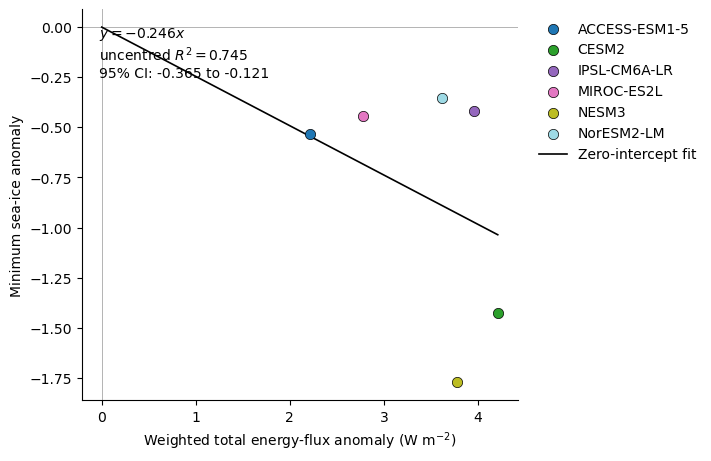

In [35]:
models = [
    model
    for model in anomaly_energy_dict
    if model in anomaly_si_dict
]

total_list = []
weighted_total_list = []
si_list = []

for model in models:
    total_list.append(
        np.sum(anomaly_energy_dict[model]["total"])
    )
    weighted_total_list.append(
        anomaly_energy_dict[model]["weighted_total"]
    )
    si_list.append(
        (np.min(paleo_si_dict[model]["siconc"] - control_si_dict[model]["siconc"]))
    )

x = np.asarray(weighted_total_list, dtype=float)
y = np.asarray(si_list, dtype=float)

# ------------------------------------------------------------
# Regression with intercept forced to zero
# ------------------------------------------------------------
intercept = 0.0
slope = np.sum(x * y) / np.sum(x**2)

y_pred = slope * x

# Uncentred R², appropriate for a zero-intercept regression
r_squared = 1 - (
    np.sum((y - y_pred)**2) /
    np.sum(y**2)
)

# ------------------------------------------------------------
# Bootstrap confidence interval for the slope
# ------------------------------------------------------------
rng = np.random.default_rng(42)
n_boot = 10_000
bootstrap_slopes = np.empty(n_boot)

for i in range(n_boot):
    indices = rng.integers(0, len(x), size=len(x))

    x_boot = x[indices]
    y_boot = y[indices]

    bootstrap_slopes[i] = (
        np.sum(x_boot * y_boot) /
        np.sum(x_boot**2)
    )

slope_lower, slope_upper = np.percentile(
    bootstrap_slopes,
    [2.5, 97.5],
)

print(f"Slope: {slope:.3f}")
print(
    f"95% bootstrap confidence interval: "
    f"{slope_lower:.3f} to {slope_upper:.3f}"
)
print(f"Zero-intercept R²: {r_squared:.3f}")

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(7.0, 4.5),
    constrained_layout=True,
)

colours = plt.colormaps["tab20"].resampled(len(models))

for i, model in enumerate(models):
    ax.scatter(
        x[i],
        y[i],
        color=colours(i),
        s=55,
        edgecolor="black",
        linewidth=0.5,
        label=model,
        zorder=3,
    )

# Use sorted x values so that the regression line is straight
x_line = np.linspace(
    min(0, x.min()),
    max(0, x.max()),
    200,
)

ax.plot(
    x_line,
    slope * x_line,
    color="black",
    linewidth=1.2,
    label="Zero-intercept fit",
    zorder=2,
)

ax.text(
    0.04,
    0.96,
    (
        rf"$y = {slope:.3f}x$"
        "\n"
        rf"uncentred $R^2 = {r_squared:.3f}$"
        "\n"
        rf"95% CI: {slope_lower:.3f} to {slope_upper:.3f}"
    ),
    transform=ax.transAxes,
    fontsize=10,
    va="top",
)

ax.axhline(0, color="0.7", linewidth=0.7, zorder=1)
ax.axvline(0, color="0.7", linewidth=0.7, zorder=1)

ax.set_xlabel("Weighted total energy-flux anomaly (W m$^{-2}$)")
ax.set_ylabel("Minimum sea-ice anomaly")

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

Text(0.05, 0.95, 'y = 0.023x + -3.580\n$R^2$ = 0.213')

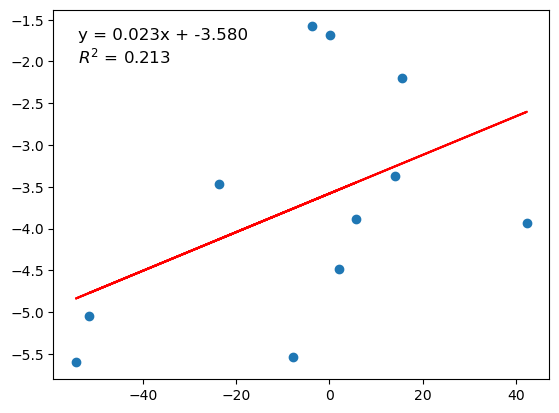

In [ ]:
#add line of best fit, with intercept forced to zero

x = np.asarray(total_list)
y = np.asarray(si_list)

plt.plot(x, y, 'o')

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
#slope = np.sum(x * y) / np.sum(x**2)
#intercept = 0.0

plt.plot(x, intercept + slope * x, 'r', label='fitted line')
#display the equation of the line and R-squared value
plt.text(0.05, 0.95, f'y = {slope:.3f}x + {intercept:.3f}\n$R^2$ = {r_value**2:.3f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')